In [1]:
# ============================================================
# LSEG JUNIOR DATA SCIENTIST ASSESSMENT
# OpenPermID Graph Data Analysis
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import re
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# ============================================================
# 2. FILE LOCATIONS
# ============================================================

# This is the folder containing main.py
PROJECT_FOLDER = Path.cwd()

# Put all seven datasets inside this folder
DATA_FOLDER = PROJECT_FOLDER / "data"

# Results will be saved here
RESULTS_FOLDER = PROJECT_FOLDER / "results"
RESULTS_FOLDER.mkdir(exist_ok=True)


# None means analyse the complete files.
MAX_LINES = None

In [3]:
# ============================================================
# 3. FIND THE DATASET FILES
# ============================================================

# Names of the datasets we need
dataset_names = [
    "assetClass",
    "currency",
    "industry",
    "instrument",
    "organization",
    "person",
    "quote"
]

# Store the location of each dataset
FILES = {}

for dataset_name in dataset_names:

    # Create the expected file path
    file_path = DATA_FOLDER / f"OpenPermID-bulk-{dataset_name}.ntriples"

    # Check whether the file exists
    if not file_path.exists():
        raise FileNotFoundError(
            f"The {dataset_name} dataset was not found.\n"
        )

    # Save the dataset path
    FILES[dataset_name] = file_path

    print(f"✓ {dataset_name:15} -> {file_path.name}")


print("\nAll dataset files were found successfully.")

✓ assetClass      -> OpenPermID-bulk-assetClass.ntriples
✓ currency        -> OpenPermID-bulk-currency.ntriples
✓ industry        -> OpenPermID-bulk-industry.ntriples
✓ instrument      -> OpenPermID-bulk-instrument.ntriples
✓ organization    -> OpenPermID-bulk-organization.ntriples
✓ person          -> OpenPermID-bulk-person.ntriples
✓ quote           -> OpenPermID-bulk-quote.ntriples

All dataset files were found successfully.


In [4]:
# ============================================================
# 4. OPEN FILES
# ============================================================

def open_dataset(file_path):
    """
    Open:
    Normal .ntriples file
    """

    if str (file_path).endswith(".ntriples"):
        return open(
        file_path,
        mode="r",
        encoding="utf-8",
        errors="replace"
    )

In [5]:
# ============================================================
# 5. SIMPLE N-TRIPLES PARSER
# ============================================================

# Matches:
# <subject> <predicate> object .
TRIPLE_PATTERN = re.compile(
    r'^\s*<([^>]*)>\s+<([^>]*)>\s+(.+?)\s*\.\s*$'
)


def clean_text(text):
    """
    Replace escaped characters with readable text.
    """
    return (
        text.replace('\\"', '"')
            .replace("\\n", " ")
            .replace("\\r", " ")
            .replace("\\t", " ")
            .replace("\\\\", "\\")
    )


def parse_line(line):
    """
    Read one N-Triples line and return:

    subject, predicate, object value, object type
    """

    line = line.strip()

    # Skip empty lines and comments
    if not line or line.startswith("#"):
        return None

    match = TRIPLE_PATTERN.match(line)

    # Skip lines that do not follow the expected format
    if not match:
        return None

    subject, predicate, raw_object = match.groups()
    raw_object = raw_object.strip()

    # Object is a URI
    if raw_object.startswith("<") and raw_object.endswith(">"):
        object_value = raw_object[1:-1]
        object_type = "uri"

    # Object is a literal value such as text or a number
    elif raw_object.startswith('"'):

        literal_match = re.match(
            r'^"((?:\\.|[^"\\])*)"',
            raw_object
        )

        if literal_match:
            object_value = clean_text(literal_match.group(1))
        else:
            object_value = raw_object

        object_type = "literal"

    # Object is a blank node
    elif raw_object.startswith("_:"):
        object_value = raw_object
        object_type = "blank_node"

    # Any other object format
    else:
        object_value = raw_object
        object_type = "other"

    return subject, predicate, object_value, object_type


def local_name(uri):
    """
    Return the final readable part of a URI.

    Example:
    http://www.w3.org/1999/02/22-rdf-syntax-ns#type

    Returns:
    type
    """

    if "#" in uri:
        return uri.split("#")[-1]

    return uri.rstrip("/").split("/")[-1]


def read_triples(file_path):
    """
    Read a dataset one line at a time.

    This avoids loading the entire dataset into memory.
    """

    with open_dataset(file_path) as file:

        for line_number, line in enumerate(file, start=1):

            # Stop early when MAX_LINES has a value
            if MAX_LINES is not None and line_number > MAX_LINES:
                break

            triple = parse_line(line)

            if triple:
                yield triple

In [6]:
# ============================================================
# 6. GENERAL GRAPH PROFILING FUNCTION
# ============================================================

def profile_graph(file_path):
    """
    Analyze one N-Triples file and return its main statistics.
    """

    total_triples = 0
    unique_subjects = 0
    parsing_errors = 0
    previous_subject = None

    predicate_counts = Counter()
    entity_type_counts = Counter()
    relationship_counts = Counter()
    attribute_counts = Counter()

    with open_dataset(file_path) as file:

        for line_number, line in enumerate(file, start=1):

            # Stop after MAX_LINES when a limit is provided
            if MAX_LINES is not None and line_number > MAX_LINES:
                break

            triple = parse_line(line)

            # Count invalid lines, but ignore empty lines and comments
            if triple is None:
                clean_line = line.strip()

                if clean_line and not clean_line.startswith("#"):
                    parsing_errors += 1

                continue

            subject, predicate, object_value, object_type = triple

            total_triples += 1

            # OpenPermID normally stores each subject's triples together
            if subject != previous_subject:
                unique_subjects += 1
                previous_subject = subject

            predicate_name = local_name(predicate)
            predicate_counts[predicate_name] += 1

            # URI objects represent relationships
            if object_type == "uri":
                relationship_counts[predicate_name] += 1

                # Count the different entity types
                if predicate_name.lower() == "type":
                    entity_type = local_name(object_value)
                    entity_type_counts[entity_type] += 1

            # Literal objects represent attributes
            if object_type == "literal":
                attribute_counts[predicate_name] += 1

    results = {
        "total_triples": total_triples,
        "unique_subjects": unique_subjects,
        "unique_predicates": len(predicate_counts),
        "parsing_errors": parsing_errors,
        "predicates": predicate_counts,
        "entity_types": entity_type_counts,
        "relationships": relationship_counts,
        "attributes": attribute_counts
    }

    return results

In [7]:
# ============================================================
# 7. HELPER FUNCTIONS FOR TABLES AND CHARTS
# ============================================================

def counter_to_dataframe(counter, column_name, top_n=20):
    """
    Convert the most common Counter values into a DataFrame.
    """

    data = counter.most_common(top_n)

    return pd.DataFrame(
        data,
        columns=[column_name, "Count"]
    )


def show_profile(entity_name, profile):
    """
    Display the main results for one dataset.
    """

    print("\n" + "=" * 70)
    print(f"{entity_name.upper()} GRAPH")
    print("=" * 70)

    # General dataset information
    summary_data = {
        "Metric": [
            "Total triples",
            "Unique subjects",
            "Unique predicates",
            "Parsing errors"
        ],
        "Value": [
            profile["total_triples"],
            profile["unique_subjects"],
            profile["unique_predicates"],
            profile["parsing_errors"]
        ]
    }

    summary = pd.DataFrame(summary_data)

    print("\nGeneral summary:")
    print(summary.to_string(index=False))

    # Tables that will be displayed
    sections = [
        ("Entity types", profile["entity_types"], "Entity type"),
        ("Main relationships", profile["relationships"], "Relationship"),
        ("Main attributes", profile["attributes"], "Attribute")
    ]

    for title, counter, column_name in sections:
        table = counter_to_dataframe(counter, column_name)

        print(f"\n{title}:")
        print(table.to_string(index=False))


def plot_counter(counter, title, top_n=15):
    """
    Display the most common values in a horizontal bar chart.
    """

    data = counter_to_dataframe(
        counter,
        column_name="Name",
        top_n=top_n
    )

    # Do not create a chart when there is no data
    if data.empty:
        print(f"No data available for: {title}")
        return

    # Sort values so the largest bar appears at the top
    data = data.sort_values("Count")

    plt.figure(figsize=(10, 6))
    plt.barh(data["Name"], data["Count"])

    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [8]:
# ============================================================
# 8. ANALYSE ALL SEVEN DATASETS
# ============================================================

# Store the analysis results for every dataset
profiles = {}

for dataset_name, file_path in FILES.items():

    print(f"\nAnalysing {dataset_name}...")

    # Analyse the current dataset
    profile = profile_graph(file_path)

    # Save its results
    profiles[dataset_name] = profile

    print(
        f"Completed: {profile['total_triples']:,} triples"
    )


Analysing assetClass...
Completed: 5,961 triples

Analysing currency...
Completed: 3,879 triples

Analysing industry...
Completed: 6,380 triples

Analysing instrument...
Completed: 1,690,866 triples

Analysing organization...
Completed: 34,212,688 triples

Analysing person...
Completed: 88,868,954 triples

Analysing quote...
Completed: 10,292,470 triples


In [11]:
# ============================================================
# 9. CREATE AN OVERALL SUMMARY
# ============================================================

# Create one summary row for each dataset
summary_rows = [
    {
        "Dataset": dataset_name,
        "Total triples": profile["total_triples"],
        "Unique subjects": profile["unique_subjects"],
        "Unique predicates": profile["unique_predicates"],
        "Entity types": len(profile["entity_types"]),
        "Parsing errors": profile["parsing_errors"]
    }
    for dataset_name, profile in profiles.items()
]

# Convert the results into a DataFrame
overall_summary = pd.DataFrame(summary_rows)

# Show the largest datasets first
overall_summary = (
    overall_summary
    .sort_values("Total triples", ascending=False)
    .reset_index(drop=True)
)

# Display the summary
print("\n" + "=" * 70)
print("OVERALL DATASET SUMMARY")
print("=" * 70)

print(overall_summary.to_string(index=False))

# Save the summary as a CSV file
output_file = RESULTS_FOLDER / "overall_summary.csv"

overall_summary.to_csv(output_file, index=False)

print(f"\nSummary saved to: {output_file}")


OVERALL DATASET SUMMARY
     Dataset  Total triples  Unique subjects  Unique predicates  Entity types  Parsing errors
      person       88868954         12906804                 27             9               0
organization       34212688          4177803                 23             1               0
       quote       10292470          1317465                  9             1               0
  instrument        1690866           255879                  7             1               0
    industry           6380             1065                  6             2               0
  assetClass           5961             1363                  5             1               0
    currency           3879              459                 13             2               0

Summary saved to: e:\Downloads\LSEG_Project\results\overall_summary.csv



CURRENCY GRAPH

General summary:
           Metric  Value
    Total triples   3879
  Unique subjects    459
Unique predicates     13
   Parsing errors      0

Entity types:
    Entity type  Count
       Currency    288
CurrencySubunit    171

Main relationships:
       Relationship  Count
               type    459
       isCurrencyOf    264
isPrimaryCurrencyOf    248
isCurrencySubunitOf    171

Main attributes:
      Attribute  Count
      prefLabel    484
      hasPermId    459
isISOHistorical    459
  decimalPlaces    459
        iso4217    267
 iso4217Numeric    244
  subunitFactor    171
      subUnitLC    167
       subUnitX     27

Currency finding:
I found 2 different RDF entity types in the currency graph.


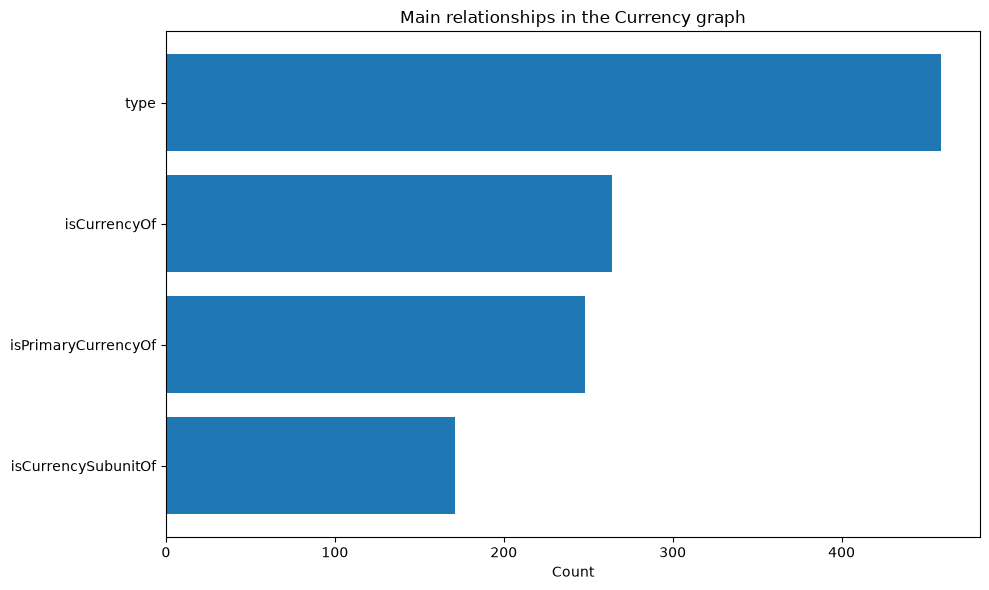

In [12]:
# ============================================================
# QUESTION 1 — CURRENCY
# ============================================================

# Get the Currency dataset results
currency_profile = profiles["currency"]

# Display the main Currency statistics
show_profile("Currency", currency_profile)

# Count the different RDF entity types
number_of_types = len(currency_profile["entity_types"])

print(
    f"\nCurrency finding:\n"
    f"I found {number_of_types:,} different RDF entity types "
    f"in the currency graph."
)

# Display the most common Currency relationships
plot_counter(
    currency_profile["relationships"],
    "Main relationships in the Currency graph"
)


ASSET CLASS GRAPH

General summary:
           Metric  Value
    Total triples   5961
  Unique subjects   1363
Unique predicates      5
   Parsing errors      0

Entity types:
Entity type  Count
 AssetClass   1363

Main relationships:
Relationship  Count
        type   1363
     broader   1292

Main attributes:
Attribute  Count
hasPermId   1363
    label   1363
  comment    580

Number of instruments by asset class:
                        Asset class             Asset class URI  Instrument count
                    Ordinary Shares https://permid.org/1-300281            202792
                             Rights https://permid.org/1-300413             17845
         Fully Paid Ordinary Shares https://permid.org/1-302539             10348
       American Depository Receipts https://permid.org/1-300016              4758
                              Units https://permid.org/1-302043              4397
                Depository Receipts https://permid.org/1-300089              3948
     

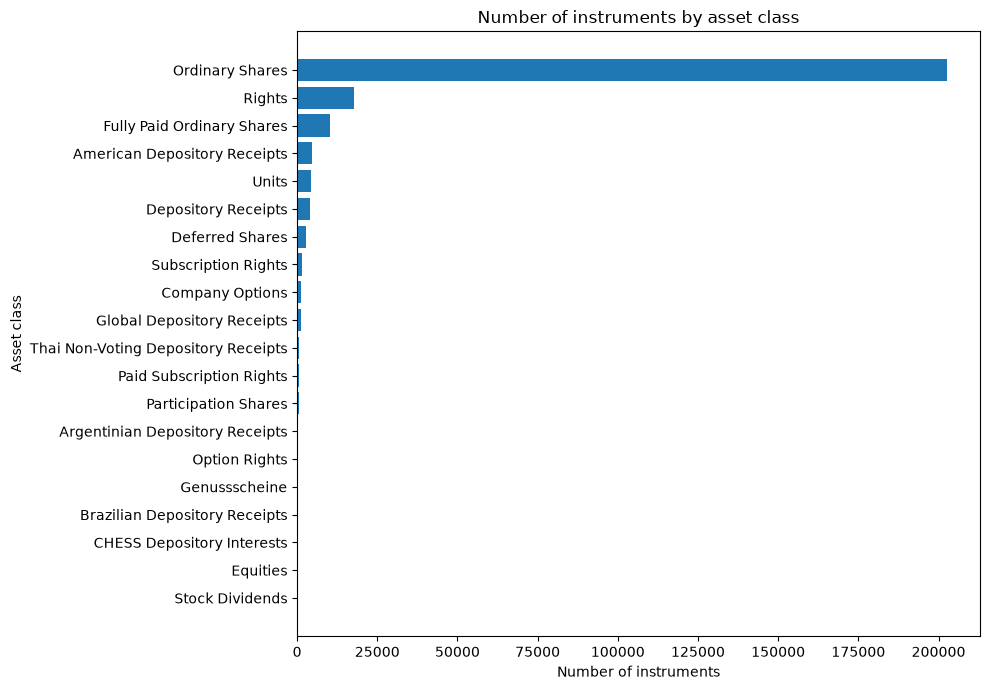

In [13]:
# ============================================================
# QUESTION 2 — ASSET CLASS
# ============================================================

# Display the general Asset Class results
asset_class_profile = profiles["assetClass"]
show_profile("Asset Class", asset_class_profile)


def get_asset_classes(file_path):
    """
    Read the Asset Class dataset and return:
    1. All asset-class URIs
    2. The readable name of each asset class
    """

    asset_class_nodes = set()
    asset_class_names = {}

    for subject, predicate, value, value_type in read_triples(file_path):

        asset_class_nodes.add(subject)
        predicate_name = local_name(predicate).lower()

        # Save a readable label or name for each asset class
        if value_type == "literal" and (
            "label" in predicate_name or "name" in predicate_name
        ):
            asset_class_names.setdefault(subject, value)

    return asset_class_nodes, asset_class_names


# Read the available asset classes and their names
asset_class_nodes, asset_class_names = get_asset_classes(
    FILES["assetClass"]
)


def count_instruments_by_asset_class(file_path):
    """
    Count the number of instruments connected to each asset class.
    """

    instrument_counts = Counter()

    current_instrument = None
    instrument_asset_classes = set()

    for subject, predicate, value, value_type in read_triples(file_path):

        # A change in subject means that a new instrument has started
        if subject != current_instrument:

            # Count the asset classes of the previous instrument
            for asset_class in instrument_asset_classes:
                instrument_counts[asset_class] += 1

            current_instrument = subject
            instrument_asset_classes = set()

        # Check whether this instrument points to an asset-class node
        if value_type == "uri" and value in asset_class_nodes:
            instrument_asset_classes.add(value)

    # Count the asset classes of the final instrument
    for asset_class in instrument_asset_classes:
        instrument_counts[asset_class] += 1

    # Convert the results into a DataFrame
    rows = [
        {
            "Asset class": asset_class_names.get(
                asset_class_uri,
                local_name(asset_class_uri)
            ),
            "Asset class URI": asset_class_uri,
            "Instrument count": count
        }
        for asset_class_uri, count in instrument_counts.most_common()
    ]

    return pd.DataFrame(rows)


# Count instruments for every asset class
assets_by_class = count_instruments_by_asset_class(
    FILES["instrument"]
)


# Display the results
print("\nNumber of instruments by asset class:")
print(assets_by_class.to_string(index=False))


# Save the results
assets_by_class.to_csv(
    RESULTS_FOLDER / "assets_by_asset_class.csv",
    index=False
)


# Plot the 20 largest asset classes
if not assets_by_class.empty:

    chart_data = (
        assets_by_class
        .head(20)
        .sort_values("Instrument count")
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        chart_data["Asset class"],
        chart_data["Instrument count"]
    )

    plt.title("Number of instruments by asset class")
    plt.xlabel("Number of instruments")
    plt.ylabel("Asset class")
    plt.tight_layout()
    plt.show()


In [18]:
# ============================================================
# QUESTION 3 — INDUSTRY
# ============================================================

# Display the general Industry dataset results
industry_profile = profiles["industry"]
show_profile("Industry", industry_profile)


def count_node_types(file_path):
    """
    Count how many nodes belong to each RDF entity type.
    """

    type_counts = Counter()

    for subject, predicate, value, value_type in read_triples(file_path):

        predicate_name = local_name(predicate).lower()

        # Count only RDF type relationships
        if predicate_name == "type" and value_type == "uri":
            entity_type = local_name(value)
            type_counts[entity_type] += 1

    return type_counts

def get_node_types(file_path):
    """
    Store the RDF type or types of every node.
    """

    node_types = defaultdict(set)

    for subject, predicate, value, value_type in read_triples(file_path):

        if (
            local_name(predicate).lower() == "type"
            and value_type == "uri"
        ):
            node_types[subject].add(
                local_name(value)
            )

    return node_types


# Create the node-type dictionary required by the network
industry_node_types = get_node_types(
    FILES["industry"]
)

print(
    f"Node types collected for "
    f"{len(industry_node_types):,} Industry nodes."
)


# Count all entity types in the Industry dataset
industry_type_counts = count_node_types(
    FILES["industry"]
)


# OpenPermID uses these names for industries and sectors
industry_count = industry_type_counts.get(
    "BusinessClassification",
    0
)

business_sector_count = industry_type_counts.get(
    "EconomicSector",
    0
)


# Display the findings
print("\nIndustry findings:")

print(
    f"Different entity types: "
    f"{len(industry_type_counts):,}"
)

print(
    f"Industries / business classifications mentioned: "
    f"{industry_count:,}"
)

print(
    f"Business / economic sectors mentioned: "
    f"{business_sector_count:,}"
)


# Save all industry entity types
industry_types_df = counter_to_dataframe(
    industry_type_counts,
    "Industry entity type",
    top_n=100
)

industry_types_df.to_csv(
    RESULTS_FOLDER / "industry_entity_types.csv",
    index=False
)



INDUSTRY GRAPH

General summary:
           Metric  Value
    Total triples   6380
  Unique subjects   1065
Unique predicates      6
   Parsing errors      0

Entity types:
           Entity type  Count
BusinessClassification   1055
        EconomicSector     10

Main relationships:
Relationship  Count
        type   1065
     broader   1055

Main attributes:
                 Attribute  Count
BusinessClassificationCode   1065
                   comment   1065
                     label   1065
                 hasPermId   1065
Node types collected for 1,065 Industry nodes.

Industry findings:
Different entity types: 2
Industries / business classifications mentioned: 1,055
Business / economic sectors mentioned: 10



Main Industry graph edges:
           Source type Relationship       Destination type  Count
BusinessClassification      broader BusinessClassification   1027
BusinessClassification      broader         EconomicSector     28


C:\Users\DELL\AppData\Local\Temp\ipykernel_24544\1263004265.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


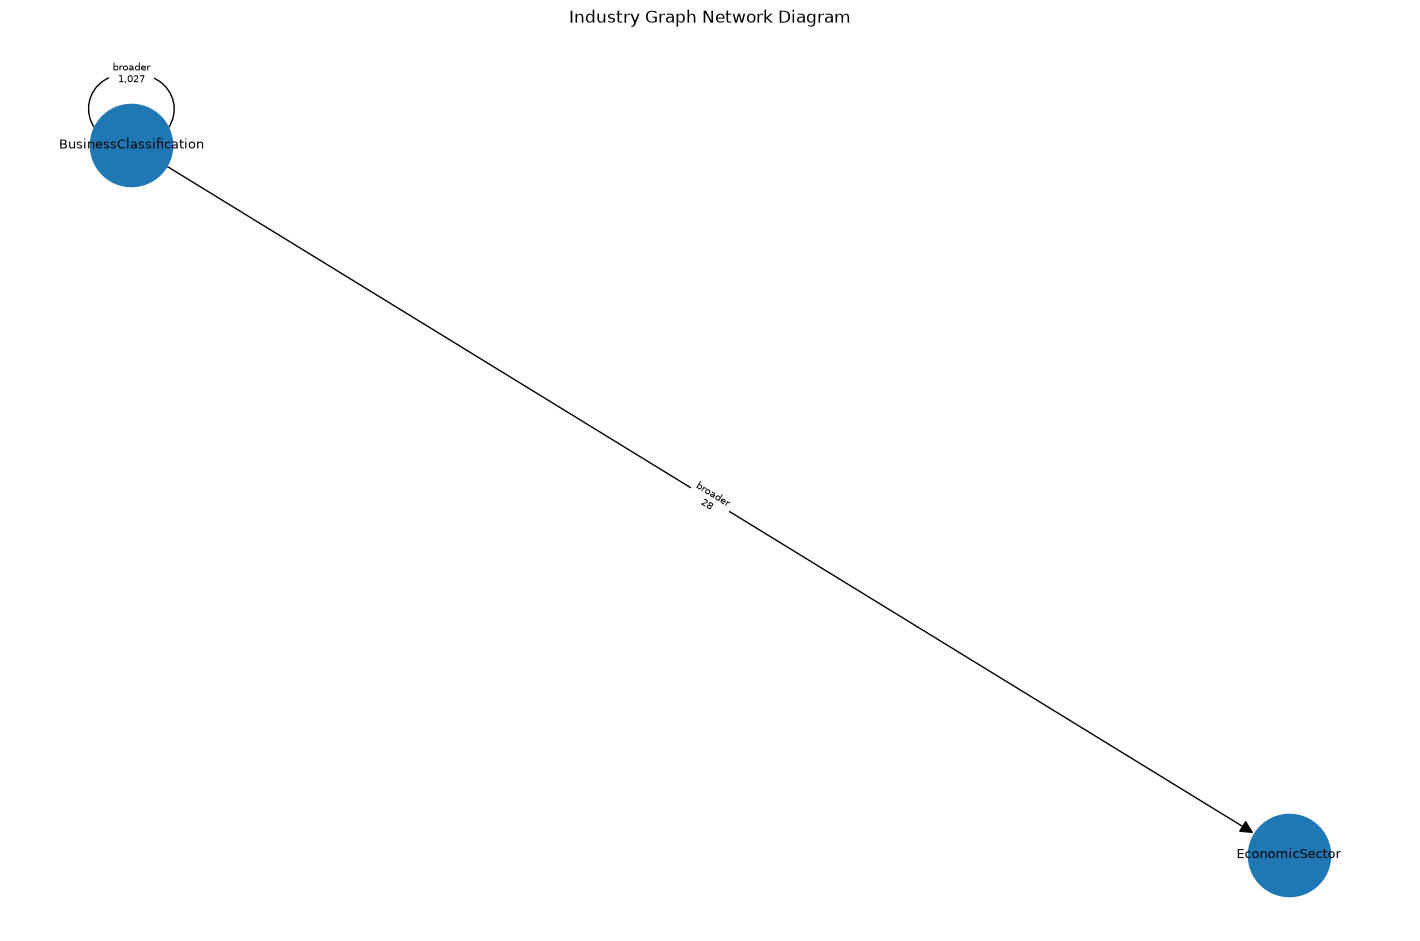

In [19]:
# ============================================================
# INDUSTRY NETWORK DIAGRAM
# ============================================================

def create_industry_network(file_path, node_types):
    """
    Count relationships between the different Industry entity types.
    """

    edge_counts = Counter()

    for subject, predicate, value, value_type in read_triples(file_path):

        # Use only URI relationships and ignore RDF type
        if value_type != "uri":
            continue

        relationship = local_name(predicate)

        if relationship.lower() == "type":
            continue

        # Find the types of the source and destination nodes
        source_types = node_types.get(subject, {"Unknown"})
        destination_types = node_types.get(value, {"External"})

        # Count every type-to-type relationship
        for source_type in source_types:
            for destination_type in destination_types:
                edge = (
                    source_type,
                    relationship,
                    destination_type
                )

                edge_counts[edge] += 1

    return edge_counts


# Count the Industry network relationships
industry_edges = create_industry_network(
    FILES["industry"],
    industry_node_types
)


# Convert the 30 most common relationships into a DataFrame
industry_edges_df = pd.DataFrame([
    {
        "Source type": source,
        "Relationship": relationship,
        "Destination type": destination,
        "Count": count
    }
    for (
        source,
        relationship,
        destination
    ), count in industry_edges.most_common(30)
])


# Display the relationship table
print("\nMain Industry graph edges:")
print(industry_edges_df.to_string(index=False))


# Save the table
industry_edges_df.to_csv(
    RESULTS_FOLDER / "industry_network_edges.csv",
    index=False
)


def draw_industry_network(edge_counts, top_n=15):
    """
    Draw the most common relationships in the Industry graph.
    """

    graph = nx.DiGraph()

    # Add the strongest relationships to the graph
    for (
        source,
        relationship,
        destination
    ), count in edge_counts.most_common(top_n):

        graph.add_edge(
            source,
            destination,
            label=f"{relationship}\n{count:,}"
        )

    # Stop when no relationships are available
    if graph.number_of_edges() == 0:
        print("No Industry relationships were available to draw.")
        return

    # Choose the position of each node
    positions = nx.spring_layout(
        graph,
        seed=42,
        k=2
    )

    plt.figure(figsize=(14, 9))

    # Draw the nodes and connections
    nx.draw(
        graph,
        positions,
        with_labels=True,
        node_size=3500,
        font_size=9,
        arrows=True,
        arrowsize=20
    )

    # Add relationship names and counts
    relationship_labels = nx.get_edge_attributes(
        graph,
        "label"
    )

    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=relationship_labels,
        font_size=7
    )

    plt.title("Industry Graph Network Diagram")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Display the network diagram
draw_industry_network(industry_edges)


ORGANIZATION GRAPH

General summary:
           Metric    Value
    Total triples 34212688
  Unique subjects  4177803
Unique predicates       23
   Parsing errors        0

Entity types:
 Entity type   Count
Organization 4177805

Main relationships:
               Relationship   Count
          hasActivityStatus 4177823
                       type 4177805
              isDomiciledIn 3641258
           isIncorporatedIn 2348633
                     hasURL  859572
   hasPrimaryBusinessSector  463213
   hasPrimaryEconomicSector  463213
    hasPrimaryIndustryGroup  463213
       hasPrimaryInstrument  188931
hasOrganizationPrimaryQuote  170460
   hasHoldingClassification  123023

Main attributes:
                       Attribute   Count
               organization-name 4177863
                       hasPermId 4177805
             HeadquartersAddress 3879292
      hasHeadquartersPhoneNumber 1130829
               RegisteredAddress 1115709
hasLatestOrganizationFoundedDate  799255
        hasH

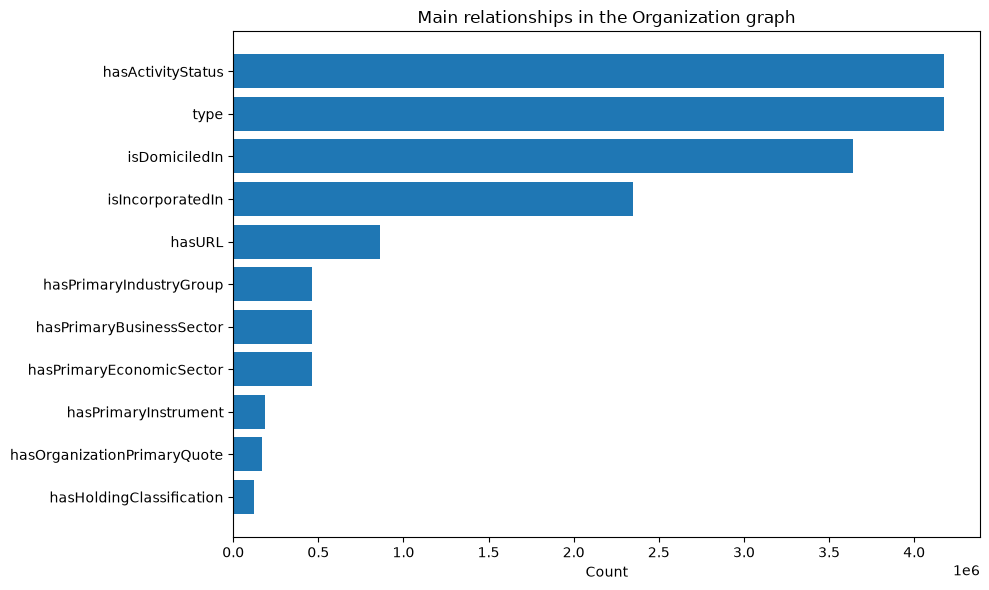

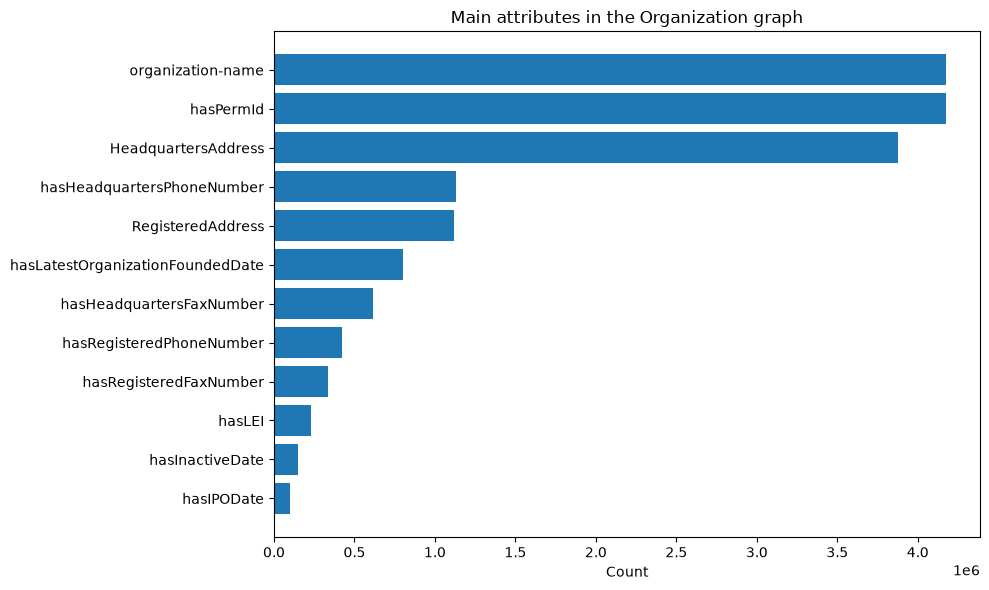

In [20]:
# ============================================================
# QUESTION 4 — ORGANIZATION
# ============================================================

organization_profile = profiles["organization"]

show_profile(
    "Organization",
    organization_profile
)

plot_counter(
    organization_profile["relationships"],
    "Main relationships in the Organization graph"
)

plot_counter(
    organization_profile["attributes"],
    "Main attributes in the Organization graph"
)


PERSON GRAPH

General summary:
           Metric    Value
    Total triples 88868954
  Unique subjects 12906804
Unique predicates       27
   Parsing errors        0

Entity types:
          Entity type   Count
               Person 4381660
 TenureInOrganization 2960027
AcademicQualification 2910156
          Officership 1676582
         Directorship  971090
                Major    7132
          OfficerRole      87
       AcademicDegree      60
         DirectorRole      10

Main relationships:
           Relationship    Count
                   type 12906804
   hasPublicationStatus  9939457
              hasHolder  5607671
             isTenureIn  2960018
        hasPositionType  2647657
           isPositionIn  2647652
          holdsPosition  2630179
       hasQualification  2624249
hasTenureInOrganization  2250920
             withDegree  2134750
              hasGender  2066081
              inSubject   897483

Main attributes:
          Attribute    Count
          hasPermId 1

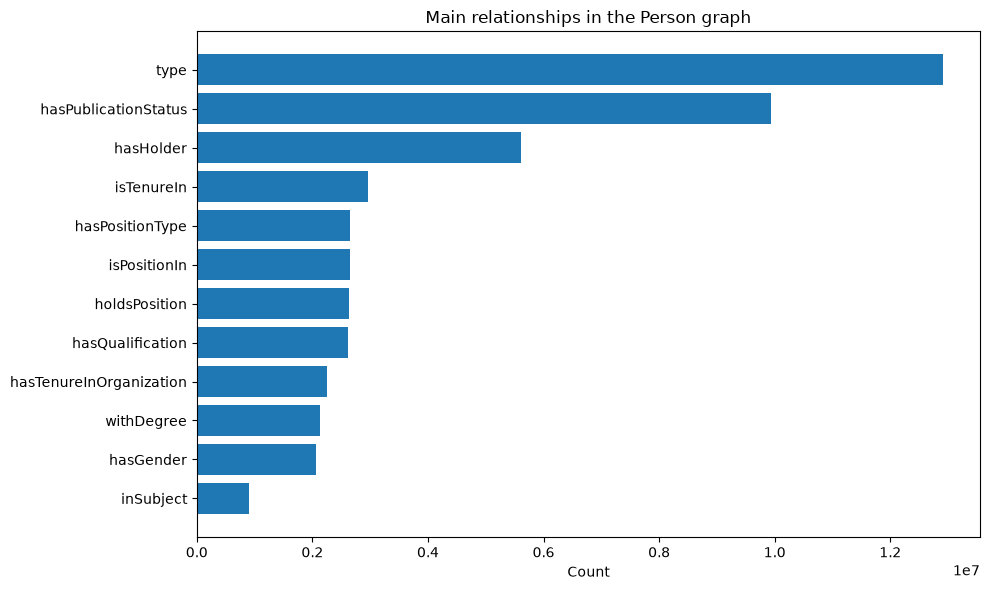

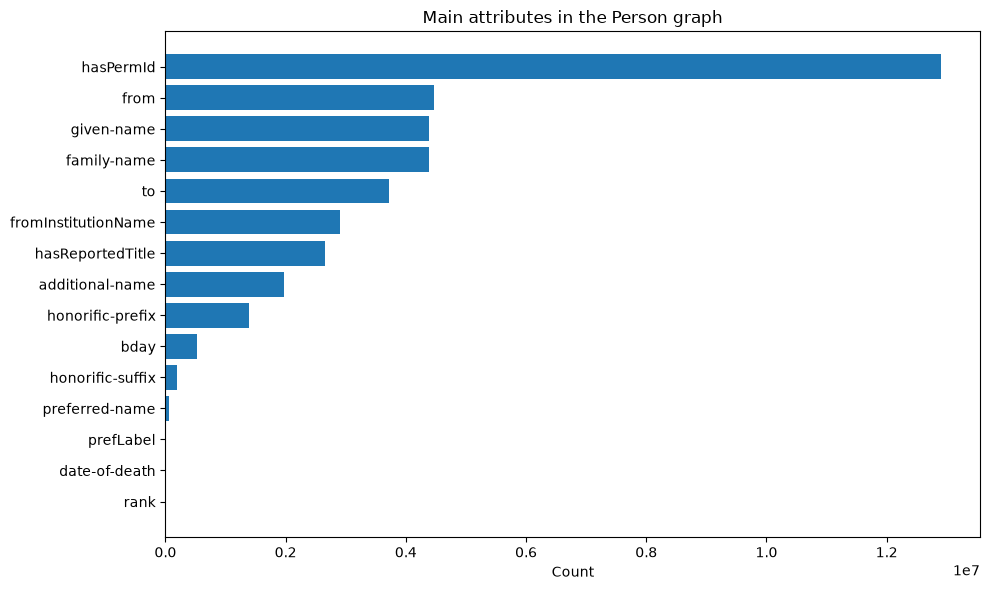

In [21]:
# ============================================================
# QUESTION 5 — PERSON
# ============================================================

person_profile = profiles["person"]

show_profile(
    "Person",
    person_profile
)

plot_counter(
    person_profile["relationships"],
    "Main relationships in the Person graph"
)

plot_counter(
    person_profile["attributes"],
    "Main attributes in the Person graph"
)


QUOTE GRAPH

General summary:
           Metric    Value
    Total triples 10292470
  Unique subjects  1317465
Unique predicates        9
   Parsing errors        0

Entity types:
Entity type   Count
      Quote 1317465

Main relationships:
Relationship   Count
   isQuoteOf 1317472
        type 1317465
  isQuotedIn 1229868

Main attributes:
        Attribute   Count
          hasName 1317481
        hasPermId 1317465
           hasRic 1317438
  hasExchangeCode 1302493
hasExchangeTicker  812294
           hasMic  360494


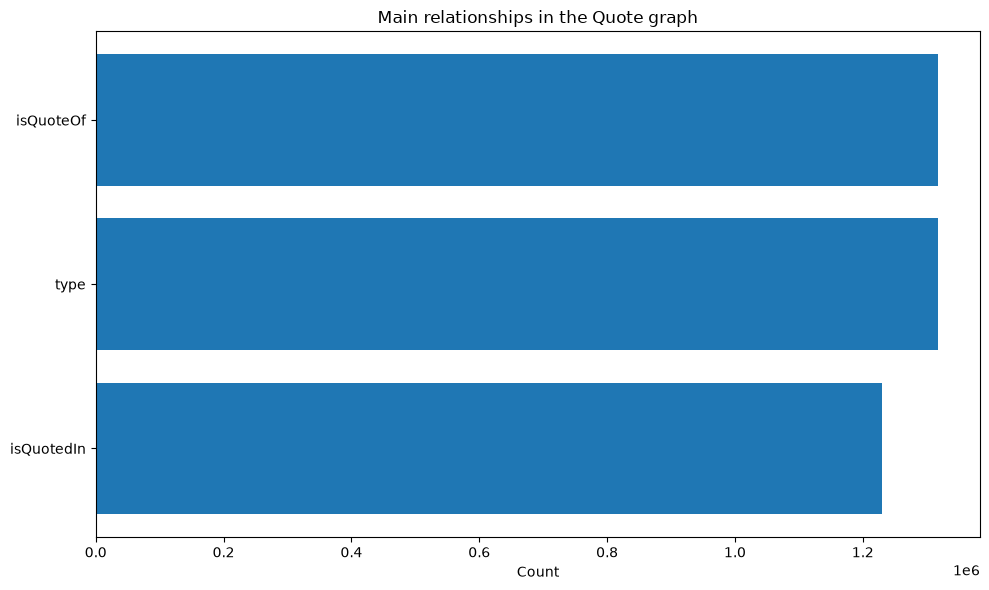

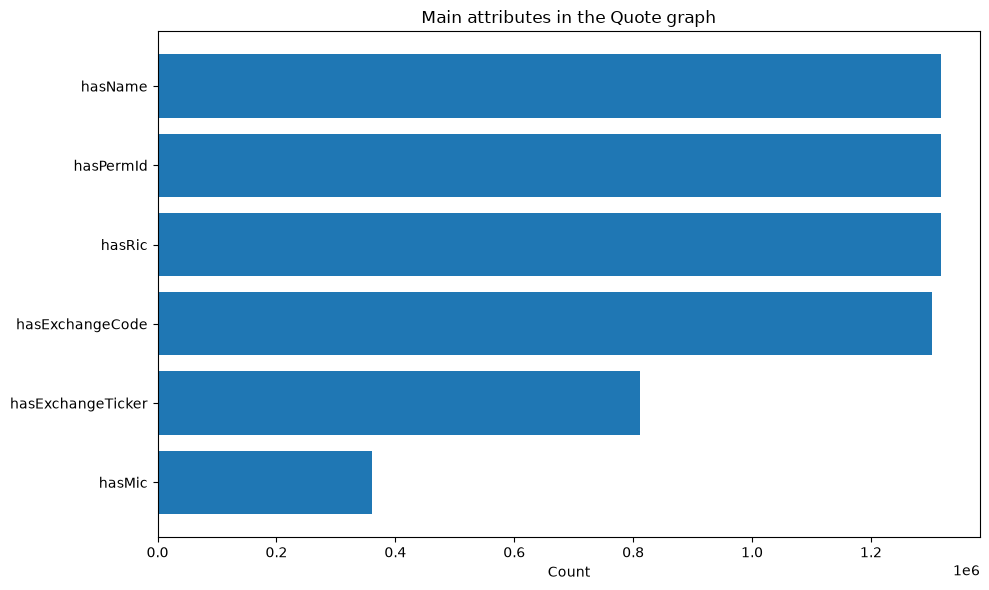

In [22]:
# ============================================================
# QUESTION 6 — QUOTE
# ============================================================

quote_profile = profiles["quote"]

show_profile(
    "Quote",
    quote_profile
)

plot_counter(
    quote_profile["relationships"],
    "Main relationships in the Quote graph"
)

plot_counter(
    quote_profile["attributes"],
    "Main attributes in the Quote graph"
)


INSTRUMENT GRAPH

General summary:
           Metric   Value
    Total triples 1690866
  Unique subjects  255879
Unique predicates       7
   Parsing errors       0

Entity types:
Entity type  Count
 Instrument 255879

Main relationships:
       Relationship  Count
               type 255879
         isIssuedBy 255879
      hasAssetClass 254761
hasInstrumentStatus 219390
    hasPrimaryQuote 193189

Main attributes:
Attribute  Count
  hasName 255889
hasPermId 255879


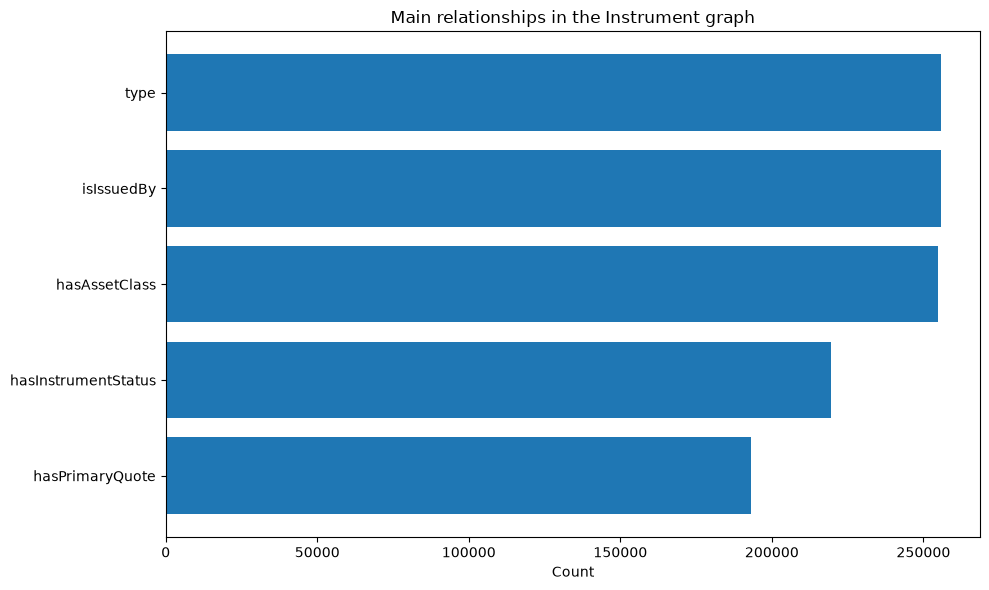

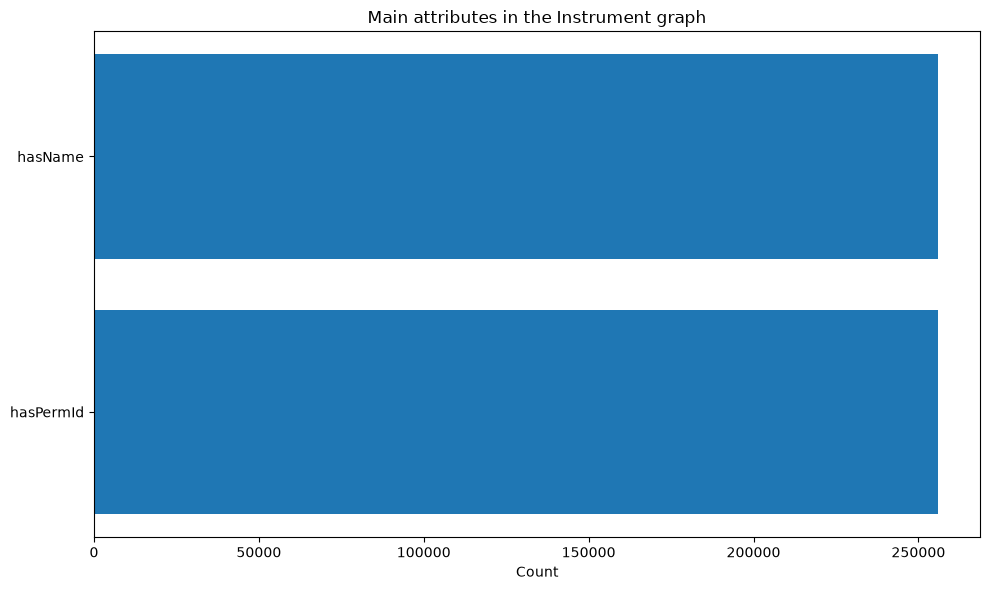

In [23]:
# ============================================================
# QUESTION 7 — INSTRUMENT
# ============================================================

instrument_profile = profiles["instrument"]

show_profile(
    "Instrument",
    instrument_profile
)

plot_counter(
    instrument_profile["relationships"],
    "Main relationships in the Instrument graph"
)

plot_counter(
    instrument_profile["attributes"],
    "Main attributes in the Instrument graph"
)

In [24]:
# ============================================================
# 10. SAVE DETAILS FOR EVERY DATASET
# ============================================================

for entity_name, profile in profiles.items():

    predicates_df = counter_to_dataframe(
        profile["predicates"],
        "Predicate",
        top_n=len(profile["predicates"])
    )

    relationships_df = counter_to_dataframe(
        profile["relationships"],
        "Relationship",
        top_n=len(profile["relationships"])
    )

    attributes_df = counter_to_dataframe(
        profile["attributes"],
        "Attribute",
        top_n=len(profile["attributes"])
    )

    entity_types_df = counter_to_dataframe(
        profile["entity_types"],
        "Entity type",
        top_n=len(profile["entity_types"])
    )

    predicates_df.to_csv(
        RESULTS_FOLDER / f"{entity_name}_predicates.csv",
        index=False
    )

    relationships_df.to_csv(
        RESULTS_FOLDER / f"{entity_name}_relationships.csv",
        index=False
    )

    attributes_df.to_csv(
        RESULTS_FOLDER / f"{entity_name}_attributes.csv",
        index=False
    )

    entity_types_df.to_csv(
        RESULTS_FOLDER / f"{entity_name}_entity_types.csv",
        index=False
    )

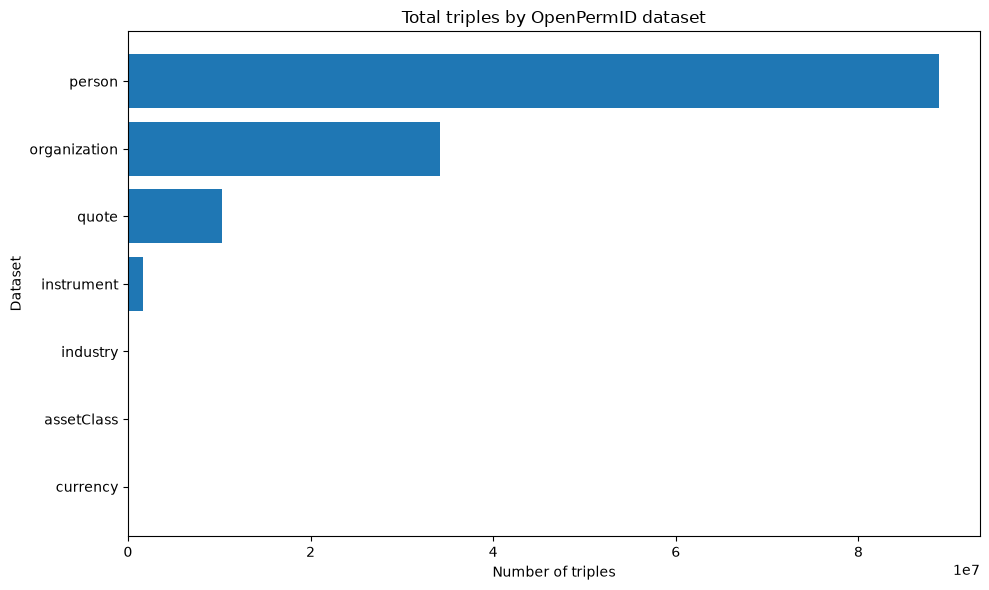

In [25]:
# ============================================================
# 11. FINAL COMPARISON CHART
# ============================================================

chart_data = overall_summary.sort_values(
    "Total triples"
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Dataset"],
    chart_data["Total triples"]
)

plt.title("Total triples by OpenPermID dataset")
plt.xlabel("Number of triples")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL ASSESSMENT SUMMARY")
print("=" * 70)

print(
    f"\nI analysed all {len(profiles)} OpenPermID datasets."
)

print(
    f"The files contain a combined total of "
    f"{overall_summary['Total triples'].sum():,} triples."
)

print(
    f"The currency graph contains "
    f"{len(currency_profile['entity_types']):,} "
    f"different entity types."
)

print(
    f"The asset-class graph contains "
    f"{asset_class_profile['unique_subjects']:,} unique subjects."
)

print(
    f"The industry graph contains "
    f"{len(industry_type_counts):,} different entity types."
)

print(
    f"I identified {industry_count:,} industries and "
    f"{business_sector_count:,} business sectors."
)

if not assets_by_class.empty:

    largest_class = assets_by_class.iloc[0]

    print(
        f"The asset class with the highest number of instrument "
        f"references is '{largest_class['Asset class']}', with "
        f"{largest_class['Instrument count']:,} instruments."
    )

print(
    f"\nAll CSV result files were saved inside:\n"
    f"{RESULTS_FOLDER}"
)

print("\nAnalysis completed successfully.")


FINAL ASSESSMENT SUMMARY

I analysed all 7 OpenPermID datasets.
The files contain a combined total of 135,081,198 triples.
The currency graph contains 2 different entity types.
The asset-class graph contains 1,363 unique subjects.
The industry graph contains 2 different entity types.
I identified 1,055 industries and 10 business sectors.
The asset class with the highest number of instrument references is 'Ordinary Shares', with 202,792 instruments.

All CSV result files were saved inside:
e:\Downloads\LSEG_Project\results

Analysis completed successfully.
